data size: 20

=== PART A.) CUBIC SPLINE ===
tridiagonal condition number:  6.82
M[0]:  0.0
M[-1]:  0.0

interpolation check: 
max error at knots:  0.0

continuity check:
max c1 gap: 7.105427357601002e-15
max c2 gap: 2.842170943040401e-14


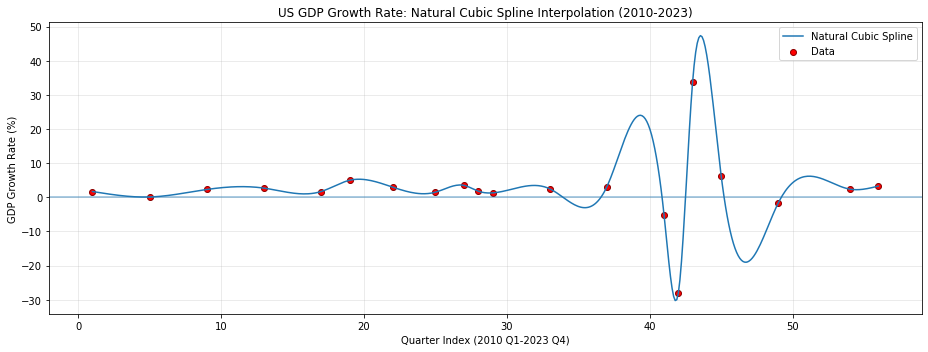


=== B1.) DEGREE 4 POLY FIT ===
degree 4 normal equations condition number:  265.0
coefficients:  [1.8957, -1.142, 0.4314, 0.5951, -0.1034]
degree 4 poly rsme:  10.0314 %
cubic spline rsme:  0.0 %


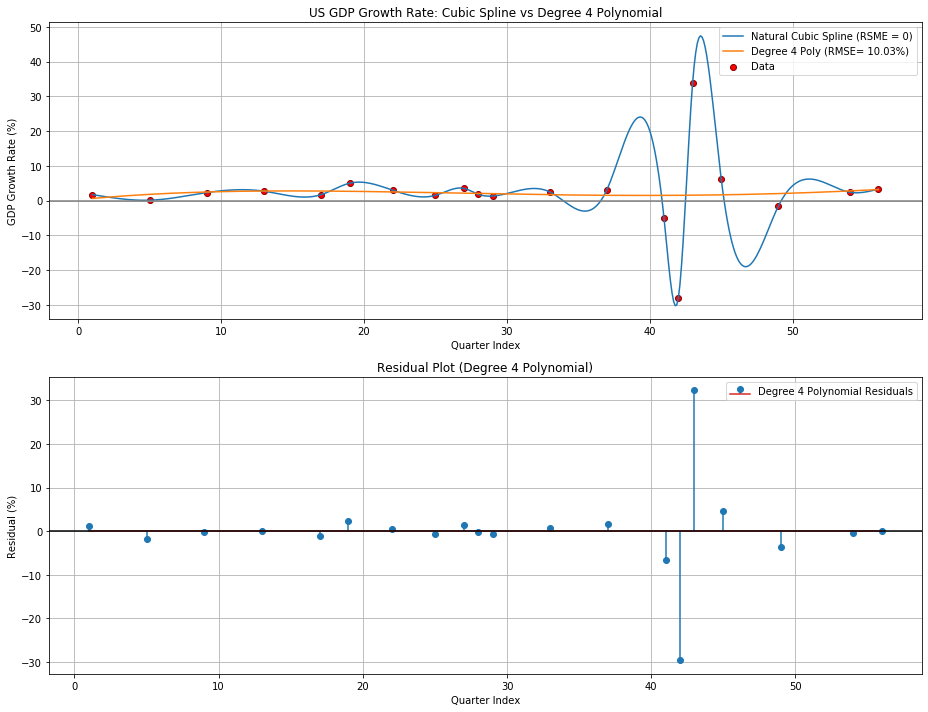


=== PART B2.) LINEAR LEAST SQUARES (NO COVID) ===
points after removing covid quarters: 16   (removed:  4 )
intercept b0:  2.1943
slope b1:  -0.0019 %/quarter
condition number:  3605.6
linear ls rmse (no covid):  1.4432 %


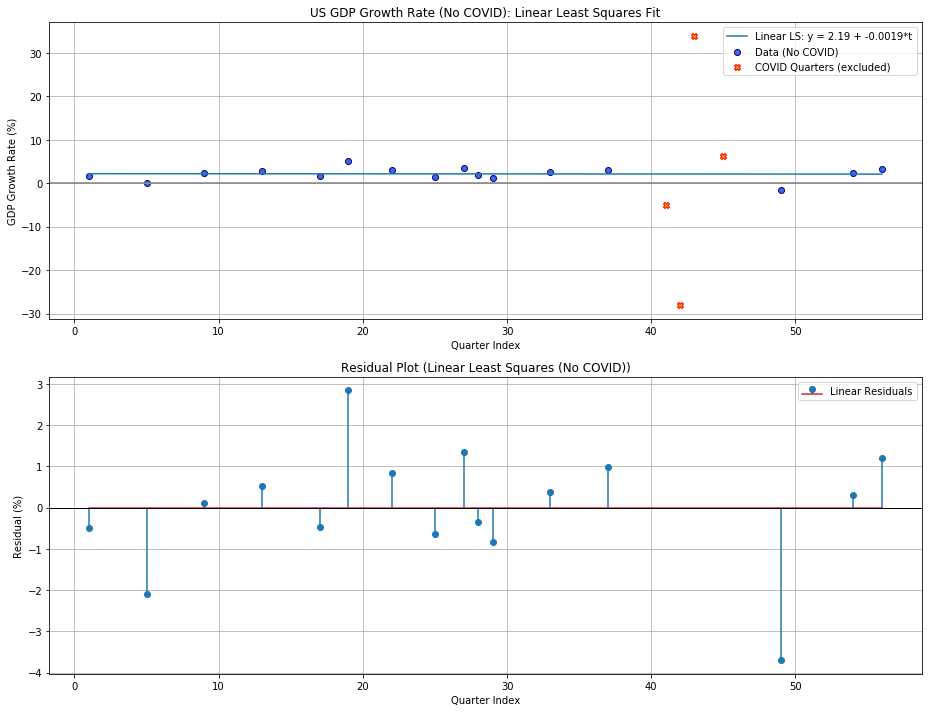

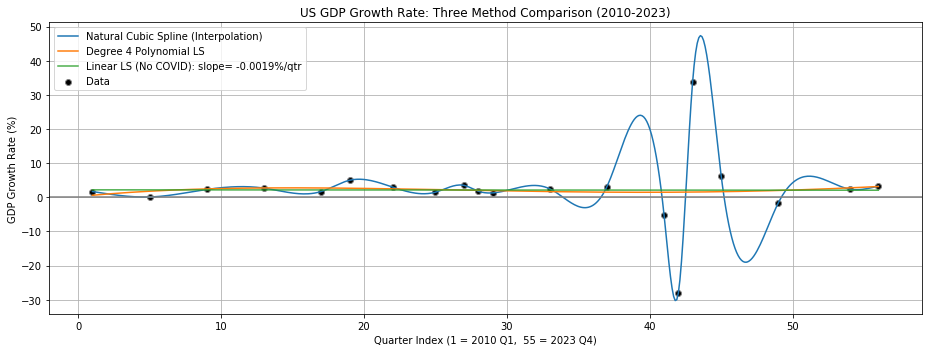


=== RESULTS SUMMARY ===
Cubic Spline RMSE:                     0.0 %
Degree 4 Polynomial RMSE:              10.0314 %
Linear LS RMSE (No COVID):             1.4432 %
Linear Slope:                          -0.0019 %/quarter
Linear Intercept:                      2.1943 %
Degree 4 Polynomial Condition Number:  265.0
Linear LS Condition Number:            3605.6


In [4]:
import numpy as np
import matplotlib.pyplot as plt


# quarter labels
quarters_labels = [
    "2010 Q1", "2011 Q1", "2012 Q1", "2013 Q1", "2014 Q1", "2014 Q3",
    "2015 Q2", "2016 Q1", "2016 Q3", "2016 Q4",
    "2017 Q1", "2018 Q1", "2019 Q1", "2020 Q1", "2020 Q2", "2020 Q3",
    "2021 Q1", "2022 Q1", "2023 Q2", "2023 Q4"
]

# gdp values
gdp_values = [
    1.7, 0.1, 2.3, 2.7, 1.7, 5.0,
    3.0, 1.5, 3.5, 1.8,
    1.3, 2.5, 3.1, -5.1, -28.1, 33.8,
    6.3, -1.6, 2.4, 3.3
]

## convert quarter to numbers
def quarter_to_index(label):
    parts = label.split()
    year = int(parts[0])
    q_num = int(parts[1][1])   # "Q1" -> 1, "Q2" -> 2, etc.
    index = (year - 2010) * 4 + (q_num - 1) + 1
    return index

x_data = []
for label in quarters_labels:
    x_data.append(float(quarter_to_index(label)))

y_data = []
for val in gdp_values:
    y_data.append(float(val))

n = len(x_data)
print("data size:", n)

# full range of quarters
x_full = []
for i in range(1, 57):
    x_full.append(float(i))

## x values plotting
x_smooth = []
step = (x_full[-1] - x_full[0]) / 499.0
for i in range(500):
    x_smooth.append(x_full[0] + i * step)


# ============================================================
# part a.) natural cubic spline
# ============================================================

def natural_cubic(x, y):
    n = len(x)

    # interval widths h[i] = x[i+1] - x[i]
    h = []
    for i in range(n - 1):
        h.append(x[i+1] - x[i])

    # tridiagonal system for M[1] - M[n-2]
    size = n - 2

    # matrix A and rhs
    A = []
    for row in range(size):
        A.append([0.0] * size)
    rhs = [0.0] * size

    for i in range(size):
        k = i + 1
        A[i][i] = 2.0 * (h[k-1] + h[k])
        if i > 0:
            A[i][i-1] = h[k-1]
        if i < size - 1:
            A[i][i+1] = h[k]
        rhs[i] = 6.0 * ( (y[k+1] - y[k]) / h[k]  -  (y[k] - y[k-1]) / h[k-1] )

    # solve
    A_np  = np.array(A)
    r_np  = np.array(rhs)
    M_interior = np.linalg.solve(A_np, r_np)

    # full M array
    M = [0.0] * n
    for i in range(size):
        M[i + 1] = M_interior[i]

    cond = np.linalg.cond(A_np)
    print("tridiagonal condition number: ", round(cond, 2))

    # find a, b, c, d for each of n-1 intervals
    coeffs = []
    for i in range(n - 1):
        a_i = y[i]
        b_i = (y[i+1] - y[i]) / h[i]  -  h[i] * (2.0*M[i] + M[i+1]) / 6.0
        c_i = M[i] / 2.0
        d_i = (M[i+1] - M[i]) / (6.0 * h[i])
        coeffs.append((a_i, b_i, c_i, d_i))

    return coeffs, M


def eval_spline(coeffs, x_knots, t):
    # restrict t
    if t < x_knots[0]:
        t = x_knots[0]
    if t > x_knots[-1]:
        t = x_knots[-1]

    # find t interval
    idx = 0
    for i in range(len(x_knots) - 1):
        if t >= x_knots[i]:
            idx = i

    a, b, c, d = coeffs[idx]
    dt = t - x_knots[idx]
    return a + b*dt + c*dt**2 + d*dt**3

def eval_spline_list(coeffs, x_knots, t_list):
    result = []
    for t in t_list:
        result.append( eval_spline(coeffs, x_knots, t) )
    return result

# build spline
print("\n=== PART A.) CUBIC SPLINE ===")
spline_coeffs, M_values = natural_cubic(x_data, y_data)
print("M[0]: ", round(M_values[0], 10))
print("M[-1]: ", round(M_values[-1], 10))

# check error
print("\ninterpolation check: ")
max_err = 0.0
for i in range(n):
    y_check = eval_spline(spline_coeffs, x_data, x_data[i])
    err = abs(y_check - y_data[i])
    if err > max_err:
        max_err = err
print("max error at knots: ", max_err)

# check continuity
print("\ncontinuity check:")
max_c1 = 0.0
max_c2 = 0.0
for i in range(1, n - 1):
    a_l, b_l, c_l, d_l = spline_coeffs[i - 1]
    dt_l = x_data[i] - x_data[i - 1]
    f1_left = b_l + 2.0*c_l*dt_l + 3.0*d_l*dt_l**2
    f2_left = 2.0*c_l + 6.0*d_l*dt_l

    a_r, b_r, c_r, d_r = spline_coeffs[i]
    f1_right = b_r
    f2_right = 2.0 * c_r

    gap1 = abs(f1_left - f1_right)
    gap2 = abs(f2_left - f2_right)
    if gap1 > max_c1:
        max_c1 = gap1
    if gap2 > max_c2:
        max_c2 = gap2
print("max c1 gap:", max_c1)
print("max c2 gap:", max_c2)

# smooth spline
y_spline_smooth = eval_spline_list(spline_coeffs, x_data, x_smooth)
y_spline_full   = eval_spline_list(spline_coeffs, x_data, x_full)

# fig a
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(x_smooth, y_spline_smooth, label='Natural Cubic Spline')
ax.scatter(x_data, y_data, color='red',label='Data',edgecolors='darkred')
ax.axhline(0, alpha=0.5)

ax.set_xlabel('Quarter Index (2010 Q1-2023 Q4)')
ax.set_ylabel('GDP Growth Rate (%)')
ax.set_title('US GDP Growth Rate: Natural Cubic Spline Interpolation (2010-2023)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_a_spline.png')
plt.show()

# ============================================================
# part b.) polynomial and least squares
# ============================================================

# compute rmse
def compute_rmse(y_true, y_pred):
    total = 0.0
    for i in range(len(y_true)):
        total = total + (y_true[i] - y_pred[i])**2
    total = total / len(y_true)
    return total ** 0.5

# ==== b1: degree 4 polynomial ====

print("\n=== B1.) DEGREE 4 POLY FIT ===")

degree = 4

# mean and std of x data
mean_x = 0.0
for val in x_data:
    mean_x = mean_x + val
mean_x = mean_x / len(x_data)

variance = 0.0
for val in x_data:
    variance = variance + (val - mean_x)**2
variance = variance / len(x_data)
std_x = variance ** 0.5

# scale x values
x_scaled = []
for val in x_data:
    x_scaled.append( (val - mean_x) / std_x )

# vandermonde matrix
V = []
for i in range(n):
    row = []
    for j in range(degree + 1):
        row.append( x_scaled[i] ** j )
    V.append(row)

V_np = np.array(V)
y_np = np.array(y_data)

# normal eqs
VtV = V_np.T @ V_np
Vty = V_np.T @ y_np

cond_poly = np.linalg.cond(VtV)
print("degree 4 normal equations condition number: ", round(cond_poly, 1))

c_poly = np.linalg.solve(VtV, Vty)
print("coefficients: ", [round(v, 4) for v in c_poly])

# evaluate polynomial
def eval_poly(c, x_vals, mean_x, std_x):
    result = []
    for val in x_vals:
        xs = (val - mean_x) / std_x
        y_val = 0.0
        for j in range(len(c)):
            y_val = y_val + c[j] * xs**j
        result.append(y_val)
    return result

y_poly_data   = eval_poly(c_poly, x_data,   mean_x, std_x)
y_poly_smooth = eval_poly(c_poly, x_smooth, mean_x, std_x)

# residuals and rsme
residuals_poly = []
for i in range(n):
    residuals_poly.append(y_data[i] - y_poly_data[i])

rmse_poly = compute_rmse(y_data, y_poly_data)
rmse_spline = compute_rmse(y_data, eval_spline_list(spline_coeffs, x_data, x_data))
print("degree 4 poly rsme: ", round(rmse_poly, 4), "%")
print("cubic spline rsme: ", round(rmse_spline, 8), "%")

# figure b1
fig, axes = plt.subplots(2, 1, figsize=(13, 10))

ax = axes[0]
ax.plot(x_smooth, y_spline_smooth, label='Natural Cubic Spline (RSME = 0)')
ax.plot(x_smooth, y_poly_smooth, label='Degree 4 Poly (RMSE= ' + str(round(rmse_poly, 2)) + '%)')
ax.scatter(x_data, y_data, color='red', label='Data',edgecolors='darkred')
ax.axhline(0, color='gray')
ax.set_xlabel('Quarter Index')
ax.set_ylabel('GDP Growth Rate (%)')
ax.set_title('US GDP Growth Rate: Cubic Spline vs Degree 4 Polynomial')
ax.legend()
ax.grid()

ax2 = axes[1]
ax2.stem(x_data, residuals_poly, use_line_collection='True', label='Degree 4 Polynomial Residuals')
ax2.axhline(0, color='black')
ax2.set_xlabel('Quarter Index')
ax2.set_ylabel('Residual (%)')
ax2.set_title('Residual Plot (Degree 4 Polynomial)')
ax2.legend()
ax2.grid()

plt.tight_layout()
plt.savefig('fig_b1_poly.png')
plt.show()

# ==== part b2.) linear lst sq (no covid quarters) ====

print("\n=== PART B2.) LINEAR LEAST SQUARES (NO COVID) ===")

covid_indices = []
for label in ["2020 Q1", "2020 Q2", "2020 Q3", "2021 Q1"]:
    covid_indices.append( quarter_to_index(label) )

x_nc = []
y_nc = []
for i in range(n):
    if x_data[i] not in covid_indices:
        x_nc.append(x_data[i])
        y_nc.append(y_data[i])

print("points after removing covid quarters:", len(x_nc), "  (removed: ", n - len(x_nc), ")")

# matrix A_lin
A_lin = []
for val in x_nc:
    A_lin.append([1.0, val])

A_np2 = np.array(A_lin)
y_np2 = np.array(y_nc)

AtA = A_np2.T @ A_np2
Aty = A_np2.T @ y_np2

cond_lin = np.linalg.cond(AtA)
b_lin = np.linalg.solve(AtA, Aty)

b0 = b_lin[0]
b1 = b_lin[1]
print("intercept b0: ", round(b0, 4))
print("slope b1: ", round(b1, 4), "%/quarter")
print("condition number: ", round(cond_lin, 1))

# evaluate linear model
y_lin_nc = []
for val in x_nc:
    y_lin_nc.append(b0 + b1 * val)

y_lin_smooth = []
for val in x_smooth:
    y_lin_smooth.append(b0 + b1 * val)

residuals_lin = []
for i in range(len(x_nc)):
    residuals_lin.append(y_nc[i] - y_lin_nc[i])

rmse_lin = compute_rmse(y_nc, y_lin_nc)
print("linear ls rmse (no covid): ", round(rmse_lin, 4), "%")

# figure b2
fig, axes = plt.subplots(2, 1, figsize=(13, 10))

ax = axes[0]
ax.scatter(x_nc, y_nc, color='royalblue', label='Data (No COVID)', edgecolors='navy')

# plot covid points separately
x_covid = []
y_covid = []
for i in range(n):
    if x_data[i] in covid_indices:
        x_covid.append(x_data[i])
        y_covid.append(y_data[i])
ax.scatter(x_covid, y_covid, color='orange', label='COVID Quarters (excluded)', edgecolors='red', marker='X')

ax.plot(x_smooth, y_lin_smooth, label='Linear LS: y = ' + str(round(b0, 2)) + ' + ' + str(round(b1, 4)) + '*t')
ax.axhline(0, color='gray')
ax.set_xlabel('Quarter Index')
ax.set_ylabel('GDP Growth Rate (%)')
ax.set_title('US GDP Growth Rate (No COVID): Linear Least Squares Fit')
ax.legend()
ax.grid()

ax2 = axes[1]
ax2.stem(x_nc, residuals_lin, use_line_collection='True', label='Linear Residuals')
ax2.axhline(0, color='black', linewidth=1)
ax2.set_xlabel('Quarter Index')
ax2.set_ylabel('Residual (%)')
ax2.set_title('Residual Plot (Linear Least Squares (No COVID))')
ax2.legend()
ax2.grid()

plt.tight_layout()
plt.savefig('fig_b2_linear.png')
plt.show()

# combined figure
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(x_smooth, y_spline_smooth, label='Natural Cubic Spline (Interpolation)')
ax.plot(x_smooth, y_poly_smooth, label='Degree 4 Polynomial LS')
ax.plot(x_smooth, y_lin_smooth, label='Linear LS (No COVID): slope= ' + str(round(b1, 4)) + '%/qtr', alpha=0.85)
ax.scatter(x_data, y_data, color='black', label='Data',edgecolors='gray')
ax.axhline(0, color='gray')
ax.set_xlabel('Quarter Index (1 = 2010 Q1,  55 = 2023 Q4)')
ax.set_ylabel('GDP Growth Rate (%)')
ax.set_title('US GDP Growth Rate: Three Method Comparison (2010-2023)')
ax.legend()
ax.grid()
plt.tight_layout()
plt.savefig('fig_combined.png')
plt.show()

# ============================================================
# SUMMARY
# ============================================================

print("\n=== RESULTS SUMMARY ===")
print("Cubic Spline RMSE:                    ", round(rmse_spline, 8), "%")
print("Degree 4 Polynomial RMSE:             ", round(rmse_poly, 4), "%")
print("Linear LS RMSE (No COVID):            ", round(rmse_lin, 4), "%")
print("Linear Slope:                         ", round(b1, 4), "%/quarter")
print("Linear Intercept:                     ", round(b0, 4), "%")
print("Degree 4 Polynomial Condition Number: ", round(cond_poly, 1))
print("Linear LS Condition Number:           ", round(cond_lin, 1))